In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

import copy
import random
import time

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cpu
Device: cpu


In [6]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Original training samples:", len(train_dataset_full))
print("Original test samples:", len(test_dataset_full))

100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.10MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 55.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


Original training samples: 60000
Original test samples: 10000


In [7]:
selected_classes = [0, 1, 2, 3, 4]

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat"
]

print("Selected classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Selected classes:
0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat


In [8]:
def dataset_to_tensors(dataset):
    X = dataset.data.float() / 255.0
    y = dataset.targets.long()

    return X, y


X_train_full, y_train_full = dataset_to_tensors(train_dataset_full)
X_test_full, y_test_full = dataset_to_tensors(test_dataset_full)

print("Training shape:", X_train_full.shape)
print("Test shape:", X_test_full.shape)

Training shape: torch.Size([60000, 28, 28])
Test shape: torch.Size([10000, 28, 28])


In [9]:
def select_classes(X, y, selected_classes):

    mask = torch.zeros_like(y, dtype=torch.bool)

    for c in selected_classes:
        mask |= (y == c)

    X_selected = X[mask]
    y_selected = y[mask]

    # Convert original labels 0,1,2,3,4
    # to new labels 0,1,2,3,4
    label_mapping = {
        old: new for new, old in enumerate(selected_classes)
    }

    y_new = torch.tensor(
        [label_mapping[int(label)] for label in y_selected],
        dtype=torch.long
    )

    return X_selected, y_new


X_train_selected, y_train_selected = select_classes(
    X_train_full,
    y_train_full,
    selected_classes
)

X_test_selected, y_test_selected = select_classes(
    X_test_full,
    y_test_full,
    selected_classes
)

print("Selected training samples:", len(y_train_selected))
print("Selected test samples:", len(y_test_selected))

Selected training samples: 30000
Selected test samples: 5000


In [10]:
X_train_selected = X_train_selected.reshape(
    X_train_selected.shape[0], -1
)

X_test_selected = X_test_selected.reshape(
    X_test_selected.shape[0], -1
)

print("Input dimension:", X_train_selected.shape[1])

Input dimension: 784


In [11]:
def stratified_split(X, y, train_ratio=0.64, val_ratio=0.16, seed=42):

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_indices = []
    val_indices = []
    test_indices = []

    num_classes = len(torch.unique(y))

    for c in range(num_classes):

        class_indices = torch.where(y == c)[0]

        # Shuffle class indices
        perm = torch.randperm(
            len(class_indices),
            generator=generator
        )

        class_indices = class_indices[perm]

        n = len(class_indices)

        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)

        train_indices.extend(
            class_indices[:n_train].tolist()
        )

        val_indices.extend(
            class_indices[n_train:n_train+n_val].tolist()
        )

        test_indices.extend(
            class_indices[n_train+n_val:].tolist()
        )

    # Shuffle final splits
    # Explicitly set dtype to torch.long to prevent IndexError when lists are empty
    train_indices = torch.tensor(train_indices, dtype=torch.long)
    val_indices = torch.tensor(val_indices, dtype=torch.long)
    test_indices = torch.tensor(test_indices, dtype=torch.long)

    train_indices = train_indices[
        torch.randperm(len(train_indices), generator=generator)
    ]

    val_indices = val_indices[
        torch.randperm(len(val_indices), generator=generator)
    ]

    test_indices = test_indices[
        torch.randperm(len(test_indices), generator=generator)
    ]

    return (
        X[train_indices],
        y[train_indices],
        X[val_indices],
        y[val_indices],
        X[test_indices],
        y[test_indices]
    )


X_train, y_train, X_val, y_val, X_test, y_test = stratified_split(
    X_train_selected,
    y_train_selected,
    train_ratio=0.80,
    val_ratio=0.20,
    seed=SEED
)

In [12]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_selected.shape)

Training: torch.Size([24000, 784])
Validation: torch.Size([6000, 784])
Test: torch.Size([5000, 784])


In [13]:
BATCH_SIZE = 100

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_selected, y_test_selected)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)

Batch size: 100


In [14]:
class FCNN(nn.Module):

    def __init__(self, hidden_layers):

        super(FCNN, self).__init__()

        layers = []

        input_size = 784

        # Hidden layers
        for nodes in hidden_layers:

            layers.append(
                nn.Linear(input_size, nodes)
            )

            layers.append(
                nn.ReLU()
            )

            input_size = nodes

        # Output layer
        layers.append(
            nn.Linear(input_size, 5)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [15]:
architectures = {

    "Architecture_3HL": [256, 128, 64],

    "Architecture_4HL": [256, 128, 64, 32],

    "Architecture_5HL": [256, 128, 64, 32, 16]

}

for name, layers in architectures.items():
    print(name, ":", layers)

Architecture_3HL : [256, 128, 64]
Architecture_4HL : [256, 128, 64, 32]
Architecture_5HL : [256, 128, 64, 32, 16]


In [16]:
LEARNING_RATE = 0.001

MOMENTUM = 0.9

RMSPROP_ALPHA = 0.99
EPS = 1e-8

BETA1 = 0.9
BETA2 = 0.999

In [17]:
def create_optimizer(model, optimizer_name):

    if optimizer_name == "SGD":

        return optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE
        )


    elif optimizer_name == "Vanilla GD":

        # Batch size = 100 as requested
        # This is technically mini-batch GD rather
        # than full-batch gradient descent.
        return optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE
        )


    elif optimizer_name == "Momentum":

        return optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE,
            momentum=MOMENTUM
        )


    elif optimizer_name == "NAG":

        return optim.SGD(
            model.parameters(),
            lr=LEARNING_RATE,
            momentum=MOMENTUM,
            nesterov=True
        )


    elif optimizer_name == "RMSProp":

        return optim.RMSprop(
            model.parameters(),
            lr=LEARNING_RATE,
            alpha=RMSPROP_ALPHA,
            eps=EPS
        )


    elif optimizer_name == "Adam":

        return optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE,
            betas=(BETA1, BETA2),
            eps=EPS
        )


    else:
        raise ValueError("Unknown optimizer")

In [18]:
optimizer_names = [
    "SGD",
    "Vanilla GD",
    "Momentum",
    "NAG",
    "RMSProp",
    "Adam"
]

print(optimizer_names)

['SGD', 'Vanilla GD', 'Momentum', 'NAG', 'RMSProp', 'Adam']


In [19]:
def calculate_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    return 100.0 * correct / total

In [20]:
def calculate_average_error(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            batch_size = y_batch.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

    return total_loss / total_samples

In [21]:
def train_model(
    model,
    optimizer_name,
    max_epochs=200,
    tolerance=1e-4,
    min_epochs=5
):

    criterion = nn.CrossEntropyLoss()

    optimizer = create_optimizer(
        model,
        optimizer_name
    )

    train_errors = []
    val_errors = []

    train_accuracies = []
    val_accuracies = []

    previous_error = None

    start_time = time.time()

    for epoch in range(max_epochs):

        model.train()

        running_loss = 0.0
        total_samples = 0

        # -----------------------------------------
        # Mini-batch training
        # -----------------------------------------
        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            batch_size = y_batch.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

        # Average training error
        train_error = (
            running_loss / total_samples
        )

        # Validation error
        val_error = calculate_average_error(
            model,
            val_loader,
            criterion
        )

        # Accuracy
        train_accuracy = calculate_accuracy(
            model,
            train_loader
        )

        val_accuracy = calculate_accuracy(
            model,
            val_loader
        )

        train_errors.append(train_error)
        val_errors.append(val_error)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # -----------------------------------------
        # Stopping criterion
        # -----------------------------------------
        if previous_error is not None:

            error_difference = abs(
                train_error - previous_error
            )

            if (
                error_difference < tolerance
                and epoch + 1 >= min_epochs
            ):

                print(
                    f"{optimizer_name}: "
                    f"Converged at epoch {epoch+1}, "
                    f"error difference = "
                    f"{error_difference:.8f}"
                )

                break

        previous_error = train_error

        # Progress
        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train Error: {train_error:.6f} | "
                f"Val Error: {val_error:.6f} | "
                f"Train Acc: {train_accuracy:.2f}% | "
                f"Val Acc: {val_accuracy:.2f}%"
            )

    training_time = time.time() - start_time

    return {
        "model": model,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "epochs": len(train_errors),
        "training_time": training_time
    }

In [ ]:
torch.manual_seed(SEED)

test_model = FCNN(
    architectures["Architecture_3HL"]
).to(device)

test_result = train_model(
    test_model,
    "Adam",
    max_epochs=100
)

print("\nNumber of epochs:",
      test_result["epochs"])

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  10 | Train Error: 0.211771 | Val Error: 0.256469 | Train Acc: 92.43% | Val Acc: 90.93%
Epoch  20 | Train Error: 0.152562 | Val Error: 0.249022 | Train Acc: 94.89% | Val Acc: 92.05%
Epoch  30 | Train Error: 0.108164 | Val Error: 0.296417 | Train Acc: 95.93% | Val Acc: 91.57%
Epoch  40 | Train Error: 0.084439 | Val Error: 0.348546 | Train Acc: 96.84% | Val Acc: 91.97%
Epoch  50 | Train Error: 0.070076 | Val Error: 0.360566 | Train Acc: 96.75% | Val Acc: 91.57%
Epoch  60 | Train Error: 0.062837 | Val Error: 0.420156 | Train Acc: 97.83% | Val Acc: 91.77%
Epoch  70 | Train Error: 0.047521 | Val Error: 0.495882 | Train Acc: 97.78% | Val Acc: 91.47%
Epoch  80 | Train Error: 0.045784 | Val Error: 0.543701 | Train Acc: 98.88% | Val Acc: 91.77%
Epoch  90 | Train Error: 0.034636 | Val Error: 0.564858 | Train Acc: 99.01% | Val Acc: 91.63%


In [23]:
all_results = {}

for architecture_name, hidden_layers in architectures.items():

    print("\n")
    print("=" * 70)
    print(architecture_name)
    print("Hidden layers:", hidden_layers)
    print("=" * 70)

    # ------------------------------------------------
    # Create ONE initial model
    # ------------------------------------------------
    torch.manual_seed(SEED)

    base_model = FCNN(
        hidden_layers
    ).to(device)

    # Save identical initial weights
    initial_state = copy.deepcopy(
        base_model.state_dict()
    )

    all_results[architecture_name] = {}

    # ------------------------------------------------
    # Train using each optimizer
    # ------------------------------------------------
    for optimizer_name in optimizer_names:

        print("\n")
        print("-" * 70)
        print("Optimizer:", optimizer_name)
        print("-" * 70)

        # Create new model
        model = FCNN(
            hidden_layers
        ).to(device)

        # Same initial weights
        model.load_state_dict(
            copy.deepcopy(initial_state)
        )

        result = train_model(
            model,
            optimizer_name,
            max_epochs=200,
            tolerance=1e-4,
            min_epochs=5
        )

        all_results[
            architecture_name
        ][optimizer_name] = result



Architecture_3HL
Hidden layers: [256, 128, 64]


----------------------------------------------------------------------
Optimizer: SGD
----------------------------------------------------------------------
Epoch  10 | Train Error: 1.523504 | Val Error: 1.511826 | Train Acc: 48.58% | Val Acc: 47.97%
Epoch  20 | Train Error: 1.126773 | Val Error: 1.099327 | Train Acc: 61.64% | Val Acc: 61.17%
Epoch  30 | Train Error: 0.809637 | Val Error: 0.800870 | Train Acc: 71.66% | Val Acc: 71.23%
Epoch  40 | Train Error: 0.625872 | Val Error: 0.621053 | Train Acc: 79.47% | Val Acc: 79.32%
Epoch  50 | Train Error: 0.516206 | Val Error: 0.510698 | Train Acc: 81.57% | Val Acc: 81.78%
Epoch  60 | Train Error: 0.455938 | Val Error: 0.446821 | Train Acc: 83.48% | Val Acc: 83.92%
Epoch  70 | Train Error: 0.415187 | Val Error: 0.404102 | Train Acc: 85.04% | Val Acc: 85.70%
Epoch  80 | Train Error: 0.389110 | Val Error: 0.376639 | Train Acc: 85.94% | Val Acc: 86.67%
Epoch  90 | Train Error: 0.372237 | Val 

In [24]:
epoch_table = []

for architecture_name in all_results:

    for optimizer_name in all_results[architecture_name]:

        result = all_results[
            architecture_name
        ][optimizer_name]

        epoch_table.append({
            "Architecture": architecture_name,
            "Optimizer": optimizer_name,
            "Convergence Epochs": result["epochs"],
            "Training Time (sec)": result["training_time"]
        })


epoch_df = pd.DataFrame(epoch_table)

print(epoch_df.to_string(index=False))

    Architecture  Optimizer  Convergence Epochs  Training Time (sec)
Architecture_3HL        SGD                 149           628.515702
Architecture_3HL Vanilla GD                 171           738.214945
Architecture_3HL   Momentum                  76           339.865404
Architecture_3HL        NAG                 112           502.111655
Architecture_3HL    RMSProp                  38           189.986504
Architecture_3HL       Adam                  52           278.554074
Architecture_4HL        SGD                 200           848.676161
Architecture_4HL Vanilla GD                 200           841.829882
Architecture_4HL   Momentum                  77           346.195898
Architecture_4HL        NAG                 116           555.221434
Architecture_4HL    RMSProp                  59           307.989188
Architecture_4HL       Adam                 190          1051.421705
Architecture_5HL        SGD                 200           860.250471
Architecture_5HL Vanilla GD       

In [25]:
accuracy_table = []

for architecture_name in all_results:

    for optimizer_name in all_results[architecture_name]:

        result = all_results[
            architecture_name
        ][optimizer_name]

        accuracy_table.append({
            "Architecture": architecture_name,
            "Optimizer": optimizer_name,
            "Train Accuracy (%)":
                result["train_accuracies"][-1],
            "Validation Accuracy (%)":
                result["val_accuracies"][-1],
            "Epochs":
                result["epochs"]
        })


accuracy_df = pd.DataFrame(
    accuracy_table
)

print(
    accuracy_df.to_string(index=False)
)

    Architecture  Optimizer  Train Accuracy (%)  Validation Accuracy (%)  Epochs
Architecture_3HL        SGD           88.283333                88.766667     149
Architecture_3HL Vanilla GD           88.570833                88.900000     171
Architecture_3HL   Momentum           91.833333                90.333333      76
Architecture_3HL        NAG           95.866667                91.450000     112
Architecture_3HL    RMSProp           95.795833                91.350000      38
Architecture_3HL       Adam           97.979167                91.800000      52
Architecture_4HL        SGD           88.087500                87.900000     200
Architecture_4HL Vanilla GD           88.004167                87.966667     200
Architecture_4HL   Momentum           94.237500                91.550000      77
Architecture_4HL        NAG           95.141667                89.583333     116
Architecture_4HL    RMSProp           97.595833                91.616667      59
Architecture_4HL       Adam 

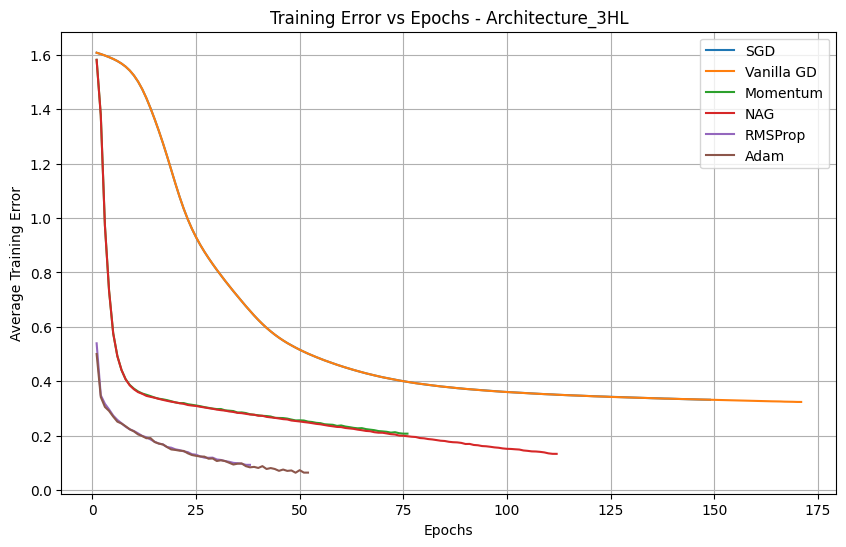

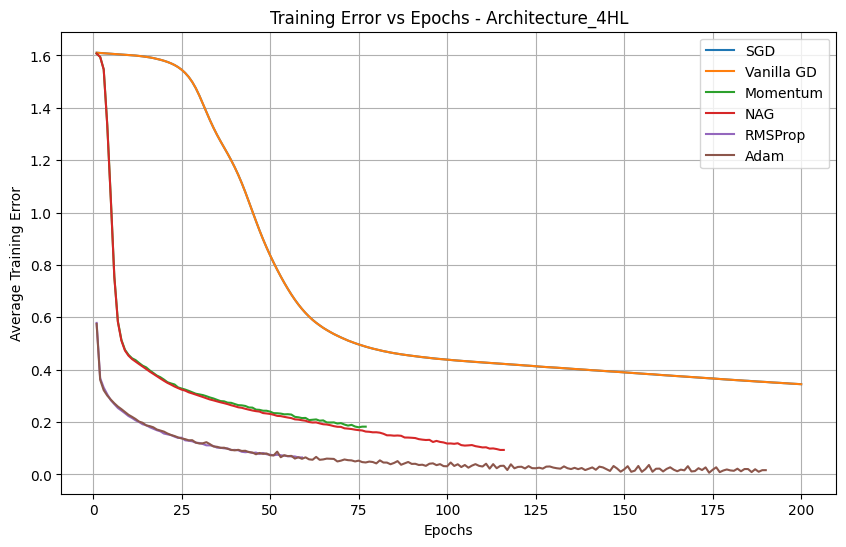

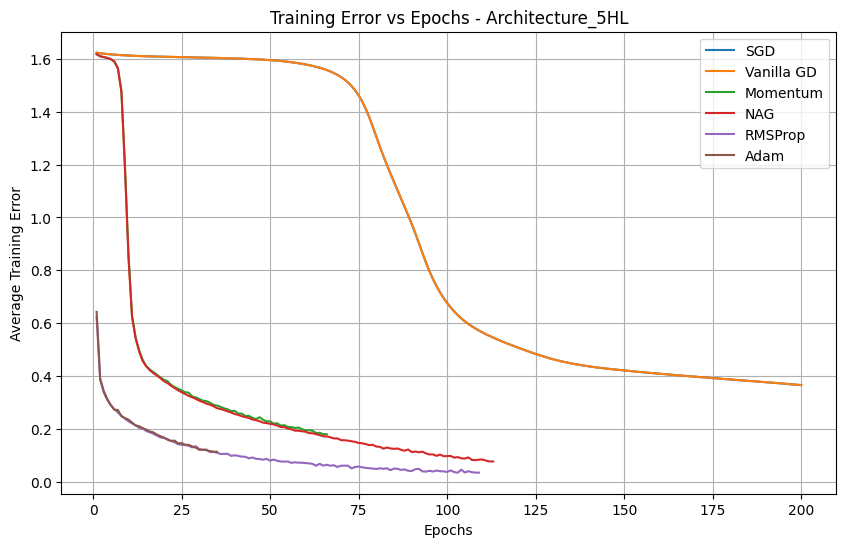

In [26]:
for architecture_name in all_results:

    plt.figure(figsize=(10, 6))

    for optimizer_name in optimizer_names:

        result = all_results[
            architecture_name
        ][optimizer_name]

        epochs = range(
            1,
            len(result["train_errors"]) + 1
        )

        plt.plot(
            epochs,
            result["train_errors"],
            label=optimizer_name
        )

    plt.xlabel("Epochs")
    plt.ylabel("Average Training Error")
    plt.title(
        f"Training Error vs Epochs - "
        f"{architecture_name}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

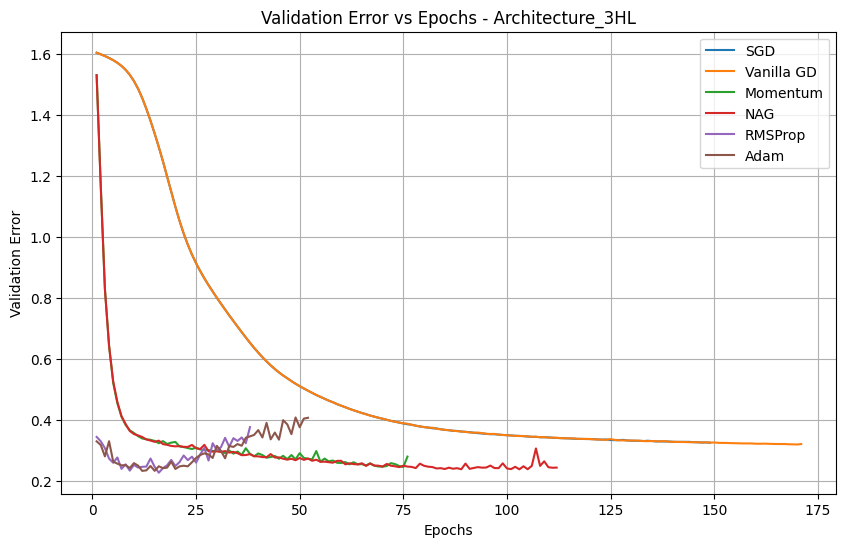

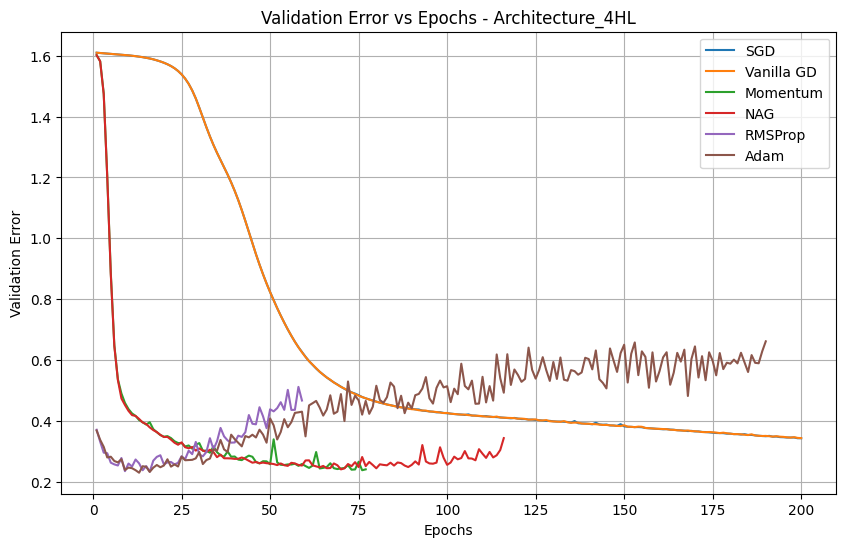

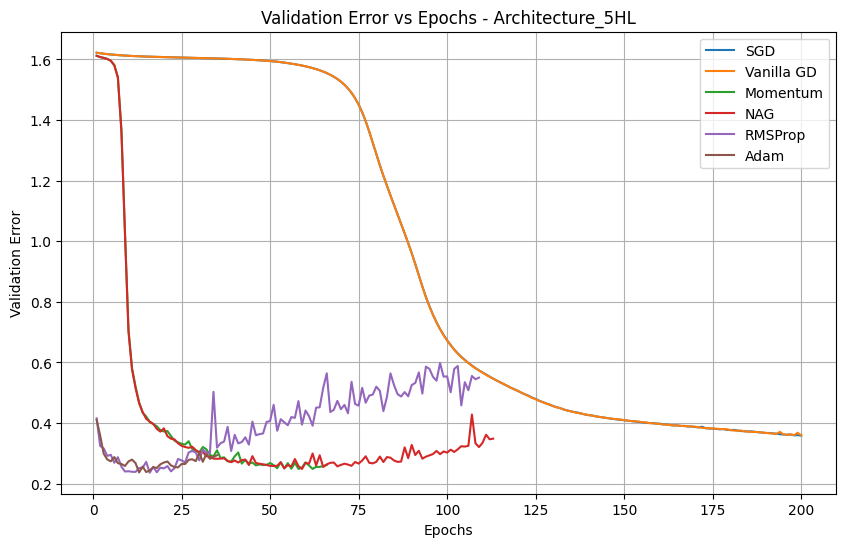

In [27]:
for architecture_name in all_results:

    plt.figure(figsize=(10, 6))

    for optimizer_name in optimizer_names:

        result = all_results[
            architecture_name
        ][optimizer_name]

        epochs = range(
            1,
            len(result["val_errors"]) + 1
        )

        plt.plot(
            epochs,
            result["val_errors"],
            label=optimizer_name
        )

    plt.xlabel("Epochs")
    plt.ylabel("Validation Error")
    plt.title(
        f"Validation Error vs Epochs - "
        f"{architecture_name}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

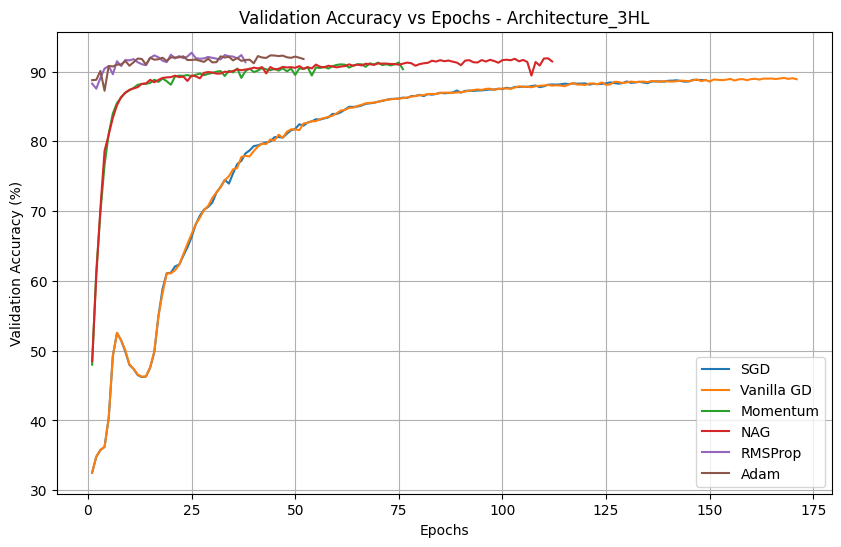

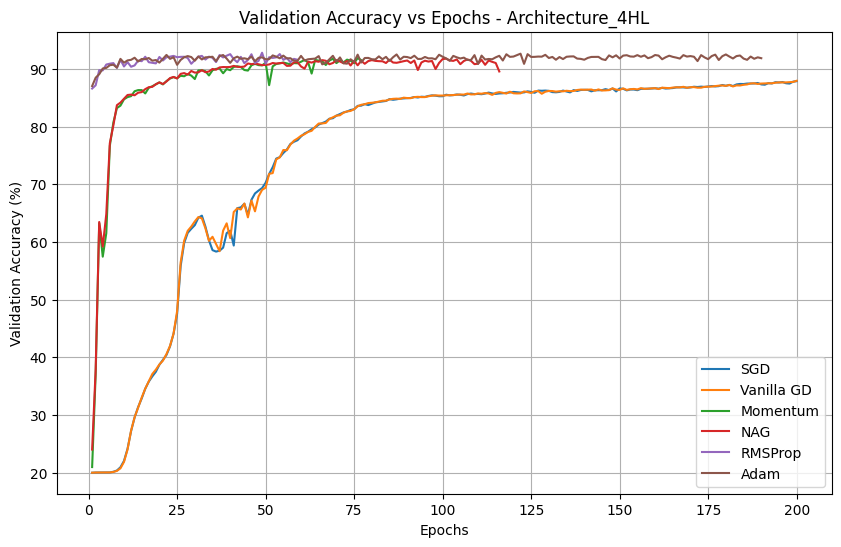

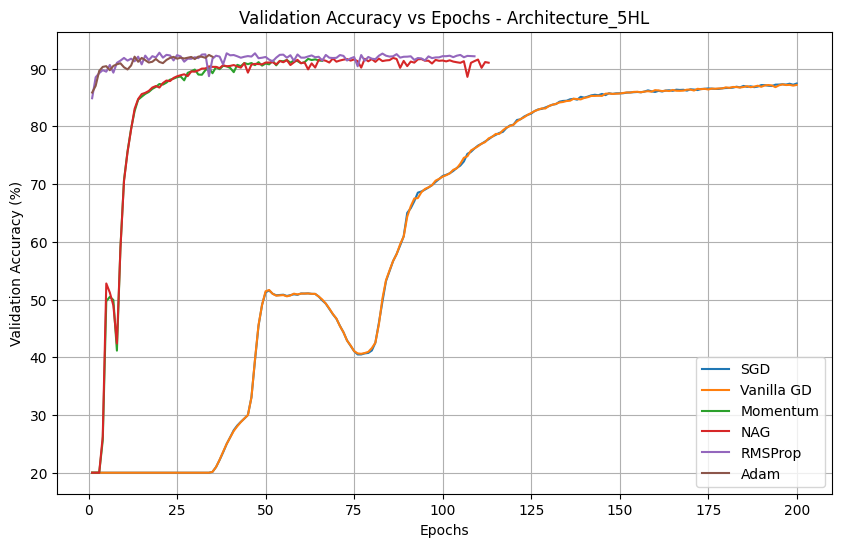

In [28]:
for architecture_name in all_results:

    plt.figure(figsize=(10, 6))

    for optimizer_name in optimizer_names:

        result = all_results[
            architecture_name
        ][optimizer_name]

        epochs = range(
            1,
            len(result["val_accuracies"]) + 1
        )

        plt.plot(
            epochs,
            result["val_accuracies"],
            label=optimizer_name
        )

    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy (%)")

    plt.title(
        f"Validation Accuracy vs Epochs - "
        f"{architecture_name}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
architecture_summary = []

for architecture_name in all_results:

    best_val_accuracy = -1
    best_optimizer = None

    for optimizer_name in all_results[architecture_name]:

        result = all_results[
            architecture_name
        ][optimizer_name]

        val_accuracy = (
            result["val_accuracies"][-1]
        )

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy
            best_optimizer = optimizer_name

    architecture_summary.append({
        "Architecture": architecture_name,
        "Best Validation Accuracy (%)":
            best_val_accuracy,
        "Optimizer":
            best_optimizer
    })


architecture_df = pd.DataFrame(
    architecture_summary
)

print(
    architecture_df.to_string(index=False)
)

    Architecture  Best Validation Accuracy (%) Optimizer
Architecture_3HL                     91.800000      Adam
Architecture_4HL                     91.883333      Adam
Architecture_5HL                     92.133333   RMSProp


In [30]:
best_architecture_row = architecture_df.loc[
    architecture_df[
        "Best Validation Accuracy (%)"
    ].idxmax()
]

best_architecture = (
    best_architecture_row["Architecture"]
)

best_optimizer = (
    best_architecture_row["Optimizer"]
)

print("Selected architecture:",
      best_architecture)

print("Optimizer with highest validation accuracy:",
      best_optimizer)

print(
    "Validation accuracy:",
    best_architecture_row[
        "Best Validation Accuracy (%)"
    ]
)

Selected architecture: Architecture_5HL
Optimizer with highest validation accuracy: RMSProp
Validation accuracy: 92.13333333333334


In [31]:
best_model = all_results[
    best_architecture
][best_optimizer]["model"]

test_accuracy = calculate_accuracy(
    best_model,
    test_loader
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 90.80%


In [32]:
def get_predictions(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                y_batch.numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )


true_labels, predicted_labels = get_predictions(
    best_model,
    test_loader
)

In [33]:
num_classes = 5

confusion_matrix = np.zeros(
    (num_classes, num_classes),
    dtype=int
)

for true, pred in zip(
    true_labels,
    predicted_labels
):

    confusion_matrix[
        true,
        pred
    ] += 1


cm_df = pd.DataFrame(
    confusion_matrix,
    index=class_names,
    columns=class_names
)

print(cm_df)

             T-shirt/top  Trouser  Pullover  Dress  Coat
T-shirt/top          937        1        20     35     7
Trouser                2      976         3     14     5
Pullover              26        0       842     10   122
Dress                 25        6        13    900    56
Coat                   3        0        89     23   885


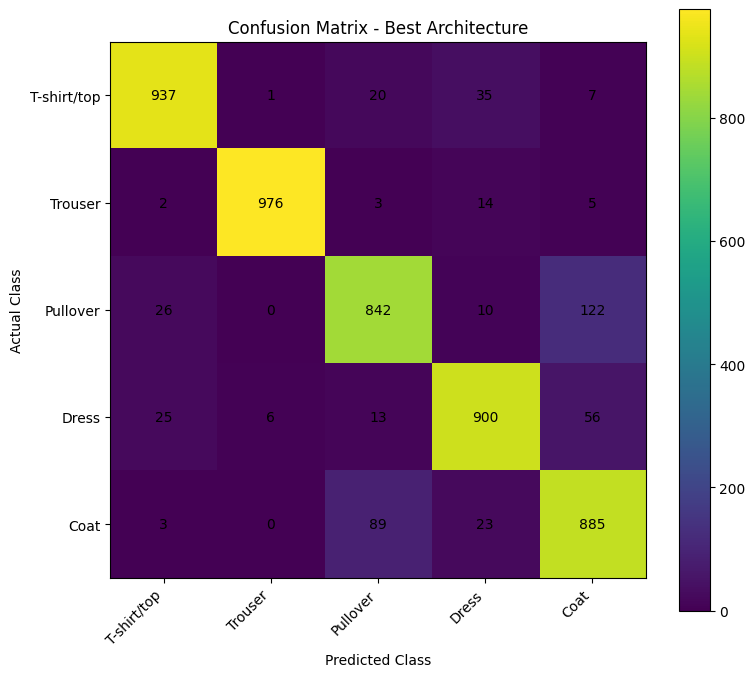

In [34]:
plt.figure(figsize=(8, 7))

plt.imshow(confusion_matrix)

plt.xticks(
    range(5),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(5),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - Best Architecture"
)

for i in range(5):
    for j in range(5):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

In [35]:
print("Per-class accuracy:\n")

for i, class_name in enumerate(class_names):

    total = confusion_matrix[i].sum()

    correct = confusion_matrix[i, i]

    accuracy = (
        100 * correct / total
    )

    print(
        f"{class_name}: "
        f"{accuracy:.2f}%"
    )

Per-class accuracy:

T-shirt/top: 93.70%
Trouser: 97.60%
Pullover: 84.20%
Dress: 90.00%
Coat: 88.50%


In [36]:
final_results = []

for architecture_name in all_results:

    for optimizer_name in optimizer_names:

        result = all_results[
            architecture_name
        ][optimizer_name]

        final_results.append({
            "Architecture":
                architecture_name,

            "Optimizer":
                optimizer_name,

            "Epochs":
                result["epochs"],

            "Train Accuracy (%)":
                round(
                    result["train_accuracies"][-1],
                    2
                ),

            "Validation Accuracy (%)":
                round(
                    result["val_accuracies"][-1],
                    2
                ),

            "Training Time (sec)":
                round(
                    result["training_time"],
                    2
                )
        })


final_df = pd.DataFrame(
    final_results
)

print(
    final_df.to_string(index=False)
)

    Architecture  Optimizer  Epochs  Train Accuracy (%)  Validation Accuracy (%)  Training Time (sec)
Architecture_3HL        SGD     149               88.28                    88.77               628.52
Architecture_3HL Vanilla GD     171               88.57                    88.90               738.21
Architecture_3HL   Momentum      76               91.83                    90.33               339.87
Architecture_3HL        NAG     112               95.87                    91.45               502.11
Architecture_3HL    RMSProp      38               95.80                    91.35               189.99
Architecture_3HL       Adam      52               97.98                    91.80               278.55
Architecture_4HL        SGD     200               88.09                    87.90               848.68
Architecture_4HL Vanilla GD     200               88.00                    87.97               841.83
Architecture_4HL   Momentum      77               94.24                    91.55  

In [37]:
epoch_df.to_csv(
    "task2_convergence_epochs.csv",
    index=False
)

final_df.to_csv(
    "task2_final_results.csv",
    index=False
)

cm_df.to_csv(
    "task2_confusion_matrix.csv"
)

print("Results saved successfully.")

Results saved successfully.
